<a href="https://colab.research.google.com/github/ajaykumar080286/DeepLearning/blob/master/5_Churn_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/DeepLearning/master/Churn_Modelling.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns=["RowNumber","CustomerId","Surname"],inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.shape

(10000, 11)

In [7]:
df["Geography"].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [8]:
df["Gender"].value_counts()

,count
Gender,
Male,5457
Female,4543


In [9]:
df["Exited"].value_counts() # this is clear case of Impalance data set

,count
Exited,
0,7963
1,2037


In [10]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
X=df.drop(columns=["Exited"])
y=df["Exited"]
X.shape

(10000, 10)

In [12]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=0)

In [13]:
columntrans=ColumnTransformer(
    transformers=[
        ("trf1", OneHotEncoder(drop="first", sparse_output=False), ["Geography","Gender"])    ]
    ,remainder="passthrough"
    )

In [14]:
X_trains_trf=columntrans.fit_transform(X_train)
X_test_trf=columntrans.transform(X_test)

In [15]:
X_trains_trf.shape

(8000, 11)

In [16]:
scale=StandardScaler()

In [17]:
X_train_f=scale.fit_transform(X_trains_trf)
X_test_f=scale.fit_transform(X_test_trf)

In [18]:
X_train_f.shape

(8000, 11)

In [19]:
X_test_f.shape

(2000, 11)

In [20]:
import tensorflow
from tensorflow import keras
from keras import  Sequential
from keras.layers import Dense

In [37]:
model=Sequential()

model.add(Dense(11,activation="relu", input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
model.compile(optimizer="Adam", loss="binary_crossentropy",metrics=["accuracy"])

In [40]:
history=model.fit(X_train_f,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7161 - loss: 0.5677 - val_accuracy: 0.7969 - val_loss: 0.4730
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8009 - loss: 0.4472 - val_accuracy: 0.7987 - val_loss: 0.4364
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8116 - loss: 0.4186 - val_accuracy: 0.8069 - val_loss: 0.4211
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8222 - loss: 0.4032 - val_accuracy: 0.8200 - val_loss: 0.4104
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8344 - loss: 0.3903 - val_accuracy: 0.8263 - val_loss: 0.3997
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8427 - loss: 0.3779 - val_accuracy: 0.8400 - val_loss: 0.3891
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8464 - loss: 0.3681 - val_accuracy: 0.8438 - val_loss: 0.3817
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8494 - loss: 0.3615 - val_accu

In [41]:
model.layers[0].get_weights()

[array([[ 0.02120037, -0.02037386, -0.1099325 ,  0.08615937,  0.06763994,
          0.36173937,  0.32900438, -0.52952665,  0.4125536 ,  0.5118853 ,
         -0.08651293],
        [ 0.02610306, -0.1426997 , -0.9936136 ,  0.5482772 , -0.04628115,
         -0.41427493,  0.37215313,  0.26304013, -0.24641407,  0.532809  ,
          0.00368855],
        [ 0.03682675,  0.11897708,  0.02317659, -0.21124436, -0.05738902,
          0.25209376,  0.28819707,  0.26439485,  0.40637854,  0.01416442,
         -0.04682435],
        [-0.06054325, -0.07060345,  0.35560712,  0.11753438, -0.0747151 ,
         -0.2326159 ,  0.37400305,  0.0789442 , -0.4054849 ,  0.3711224 ,
          0.13874595],
        [ 0.26077443,  0.7328278 , -0.8888245 , -0.65664065,  0.7107413 ,
         -0.28041798,  0.27525517, -0.405793  ,  0.12653373,  0.41474852,
         -0.03799885],
        [-0.02022927,  0.04699873,  0.08767725, -0.21206558,  0.04081574,
         -0.00706129, -0.03308294, -0.03471834,  0.36176935,  0.0325699

In [42]:
model.layers[1].get_weights()

[array([[-0.40908718, -1.1447533 , -0.3130584 , -0.3960247 , -0.85275257,
          0.68059075, -0.5753354 , -0.16082533, -0.51169926,  1.617708  ,
         -0.3267667 ],
        [ 0.19900756, -0.2008942 , -0.5959098 ,  0.21461976, -0.03565726,
         -0.64241874,  0.7836478 , -0.5669193 ,  0.467912  ,  0.23895186,
          0.7096931 ],
        [ 0.39950785, -0.18227828, -0.14974913,  0.08254671,  0.2368355 ,
         -0.20799166, -0.26887143, -0.3701826 ,  0.46805397, -0.9522464 ,
         -0.74913687],
        [ 0.7299751 , -0.14254291, -0.32225606,  0.45811242,  0.46399617,
          0.39312422,  0.35833135, -0.40122867,  0.4600121 , -0.00740293,
          0.66680086],
        [ 0.11015005,  0.61477536, -0.54368144, -0.14947084,  0.06931651,
          0.4915956 ,  0.23934475,  0.5359048 ,  0.20088051, -0.3388698 ,
          0.24801233],
        [-0.51799124, -0.28689536,  0.41215253,  0.03387157,  0.0732237 ,
          0.13011336, -0.34960523, -0.54643553, -0.14591083,  0.3025274

In [43]:
y_pred=model.predict(X_test_f)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [44]:
y_pred_binary = np.where(y_pred > 0.5, 1, 0)
accuracy_score(y_test, y_pred_binary)

0.863

In [46]:
history.history

{'accuracy': [0.7160937786102295,
  0.8009374737739563,
  0.8115624785423279,
  0.8221874833106995,
  0.8343750238418579,
  0.8426562547683716,
  0.8464062213897705,
  0.8493750095367432,
  0.8526562452316284,
  0.8526562452316284,
  0.8564062714576721,
  0.8565624952316284,
  0.8571875095367432,
  0.8579687476158142,
  0.8579687476158142,
  0.8592187762260437,
  0.8579687476158142,
  0.858593761920929,
  0.8592187762260437,
  0.858593761920929,
  0.8609374761581421,
  0.8587499856948853,
  0.8587499856948853,
  0.8618749976158142,
  0.8610937595367432,
  0.8615624904632568,
  0.8635937571525574,
  0.8621875047683716,
  0.8600000143051147,
  0.8609374761581421,
  0.860156238079071,
  0.8596875071525574,
  0.8618749976158142,
  0.8623437285423279,
  0.8614062666893005,
  0.8621875047683716,
  0.8628125190734863,
  0.8609374761581421,
  0.8621875047683716,
  0.8617187738418579,
  0.8607812523841858,
  0.8634374737739563,
  0.8628125190734863,
  0.8617187738418579,
  0.8607812523841858,
 

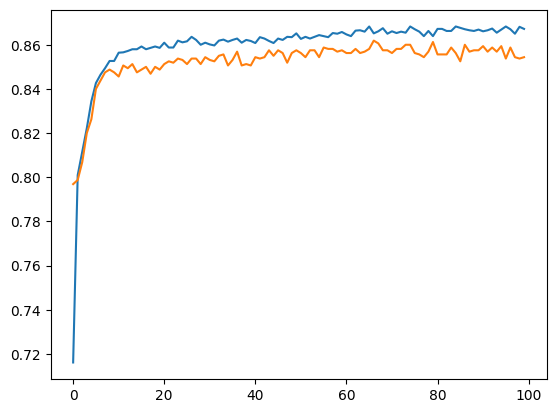

In [47]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

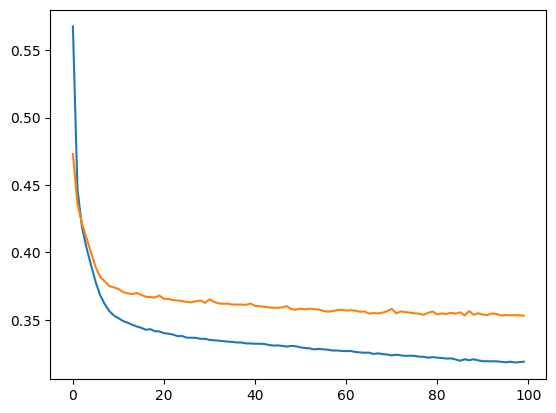

In [48]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])